# Linear Regression

- Residual Errors : Out of line (Sequence)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn

# Step 1: Finding the problem

In [4]:
df = pd.read_csv("weight-height.csv")

In [7]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
df['gender'] = df['gender'].replace({'male': 1, 'female': 0})

In [8]:
df.isnull().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 283.3 KB


In [17]:
df.corr()

ValueError: could not convert string to float: 'Male'

##### Since we want to make a model that predicts weight of a person given height of the person. So we are predicting a continous numerical value. 

Our problem regression.

Concisely our problem is Simple Linear Regression because:
 we have only one feature as input variables(predictor)
 y = w x + b

 Weight = w (Height) + B

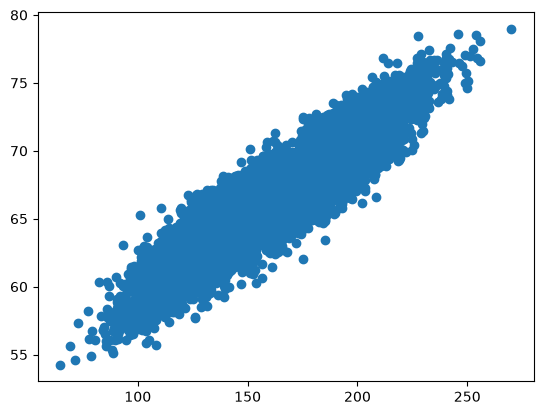

In [14]:
plt.scatter(x=df.Weight, y=df.Height)

# Step 2 : Separate input(predictor) and output (target) features

In [19]:
X = df[["Height"]]
y = df[["Weight"]]

# Step 3 : Splitting the data into training and testing set

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [58]:
import random

random.seed(5)
random.randint(1,10)

10

# Step 4 : Model Selection

In [59]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# Step 5: Model Training/Fitting

Since we are doing supervised learning.

we will train the model by supplying data plus labels (x and y both)

In [60]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[7.7]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Height']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-349.32]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [61]:
lr.coef_

array([[7.69542535]])

In [62]:
lr.intercept_

array([-349.32334861])

# Step 6 : Prediction on Training data

In [63]:
y_pred_train = lr.predict(X_train)

# Step 7 : Model Performance Evaluation

In [64]:
from sklearn.metrics import mean_squared_error, r2_score

In [65]:
mean_squared_error(y_train,y_pred_train)

149.7046382455686

In [66]:
r2_score(y_train,y_pred_train)

0.8539725668285366

# Step 8 : Prediction on Test Data

In [67]:
y_pred_test = lr.predict(X_test)

In [68]:
mean_squared_error(y_test,y_pred_test)

148.36229532793996

In [69]:
r2_score(y_test,y_pred_test)

0.8577298529881874

In [98]:
def weight_predictor(height):
    weight = lr.predict([[height]])
    return weight

In [99]:
height_inch = float(input("Enter your height in ft"))*12
print(f"Your predicted weight is: {weight_predictor(height_inch)*0.453}")

Your predicted weight is: [[105.30021607]]


C:\Users\SMIT\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Multiple Linear Regression : More than 1 input

In [79]:
df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0})

In [80]:
df.tail()

,Gender,Height,Weight
9995,0,66.172652,136.777454
9996,0,67.067155,170.867906
9997,0,63.867992,128.475319
9998,0,69.034243,163.852461
9999,0,61.944246,113.649103


In [81]:
df.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


In [83]:
X = df[["Gender","Height"]]
y = df["Weight"]

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [85]:
mlr = LinearRegression()

In [86]:
mlr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[19.4 , 5.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Gender','Height']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-243.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [87]:
mlr.coef_

array([19.40445243,  5.96180802])

In [88]:
mlr.intercept_

np.float64(-243.94905106192166)

In [89]:
y_pred_train = mlr.predict(X_train)

In [90]:
r2_score(y_train,y_pred_train)

0.902443674513295

In [91]:
y_pred_test = mlr.predict(X_test)

In [93]:
r2_score(y_test,y_pred_test)

0.9033211309502138

In [94]:
def weight_predictor(gender,height):
    weight = mlr.predict([[gender,height]])
    return weight

In [96]:
height_inch = float(input("Enter your height in ft"))*12
gender= int(input("Enter gender 1 for male and 0 for female"))
print(f"Your predicted weight is: {weight_predictor(gender,height_inch)*0.453} KG")

Your predicted weight is: [102.45414358] KG


C:\Users\SMIT\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
